In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from datetime import datetime, timedelta, timezone

import matplotlib.pyplot as plt
import polars as pl

from backtester.dtypes import SpotInstrument
from backtester import io
from utils import samplers

In [3]:
plt.rcParams["figure.facecolor"] = "darkgray"
plt.rcParams["axes.facecolor"] = "lightgray"

In [4]:
t0 = datetime(2023, 1, 1, tzinfo=timezone.utc)
tt = datetime(2023, 1, 15, tzinfo=timezone.utc)
tf = datetime(2023, 2, 28, tzinfo=timezone.utc)
dt = timedelta(hours=1)

In [5]:
path_rate = samplers.get_path_rate(t0, tf, dt)
paths_mark = samplers.get_paths_mark(t0, tf, dt)
bars_spot = paths_mark.pipe(samplers.to_bars_spot, ["binc", "cbse"], ["usd", "usdt"])
bars_option = paths_mark.pipe(samplers.to_bars_option, "drbt", "btc", "usd")

path_rate.show()
paths_mark.show()
bars_spot.show()
bars_option.show()

time_start,time_end,rate
"datetime[μs, UTC]","datetime[μs, UTC]",f64
2023-01-01 00:00:00 UTC,2023-01-01 01:00:00 UTC,0.05
2023-01-01 01:00:00 UTC,2023-01-01 02:00:00 UTC,0.049905
2023-01-01 02:00:00 UTC,2023-01-01 03:00:00 UTC,0.050247
2023-01-01 03:00:00 UTC,2023-01-01 04:00:00 UTC,0.050213
2023-01-01 04:00:00 UTC,2023-01-01 05:00:00 UTC,0.050479


time_start,time_end,name,price
"datetime[μs, UTC]","datetime[μs, UTC]",str,f64
2023-01-01 00:00:00 UTC,2023-01-01 01:00:00 UTC,"""btc""",100159.118831
2023-01-01 01:00:00 UTC,2023-01-01 02:00:00 UTC,"""btc""",99174.920298
2023-01-01 02:00:00 UTC,2023-01-01 03:00:00 UTC,"""btc""",99017.255773
2023-01-01 03:00:00 UTC,2023-01-01 04:00:00 UTC,"""btc""",98379.906424
2023-01-01 04:00:00 UTC,2023-01-01 05:00:00 UTC,"""btc""",98345.814495


time_start,time_end,base,px_mark,exchange,quote,px_bid,px_ask
"datetime[μs, UTC]","datetime[μs, UTC]",str,f64,str,str,f64,f64
2023-01-01 00:00:00 UTC,2023-01-01 01:00:00 UTC,"""btc""",100159.118831,"""binc""","""usd""",99157.527643,101160.71002
2023-01-01 01:00:00 UTC,2023-01-01 02:00:00 UTC,"""btc""",99174.920298,"""binc""","""usd""",98183.171095,100166.669501
2023-01-01 02:00:00 UTC,2023-01-01 03:00:00 UTC,"""btc""",99017.255773,"""binc""","""usd""",98027.083216,100007.428331
2023-01-01 03:00:00 UTC,2023-01-01 04:00:00 UTC,"""btc""",98379.906424,"""binc""","""usd""",97396.10736,99363.705488
2023-01-01 04:00:00 UTC,2023-01-01 05:00:00 UTC,"""btc""",98345.814495,"""binc""","""usd""",97362.35635,99329.27264


time_start,time_end,exchange,base,quote,strike,listing,expiry,kind,iv_bid,iv_ask,iv_mark
"datetime[μs, UTC]","datetime[μs, UTC]",str,str,str,f64,"datetime[μs, UTC]","datetime[μs, UTC]",str,f64,f64,f64
2023-02-27 23:00:00 UTC,2023-02-28 00:00:00 UTC,"""drbt""","""btc""","""usd""",100000.0,2023-02-24 08:00:00 UTC,2023-03-03 08:00:00 UTC,"""c""",0.99,1.01,1.0
2023-02-27 22:00:00 UTC,2023-02-27 23:00:00 UTC,"""drbt""","""btc""","""usd""",100000.0,2023-02-24 08:00:00 UTC,2023-03-03 08:00:00 UTC,"""c""",0.99,1.01,1.0
2023-02-27 21:00:00 UTC,2023-02-27 22:00:00 UTC,"""drbt""","""btc""","""usd""",100000.0,2023-02-24 08:00:00 UTC,2023-03-03 08:00:00 UTC,"""c""",0.99,1.01,1.0
2023-02-27 20:00:00 UTC,2023-02-27 21:00:00 UTC,"""drbt""","""btc""","""usd""",100000.0,2023-02-24 08:00:00 UTC,2023-03-03 08:00:00 UTC,"""c""",0.99,1.01,1.0
2023-02-27 19:00:00 UTC,2023-02-27 20:00:00 UTC,"""drbt""","""btc""","""usd""",100000.0,2023-02-24 08:00:00 UTC,2023-03-03 08:00:00 UTC,"""c""",0.99,1.01,1.0


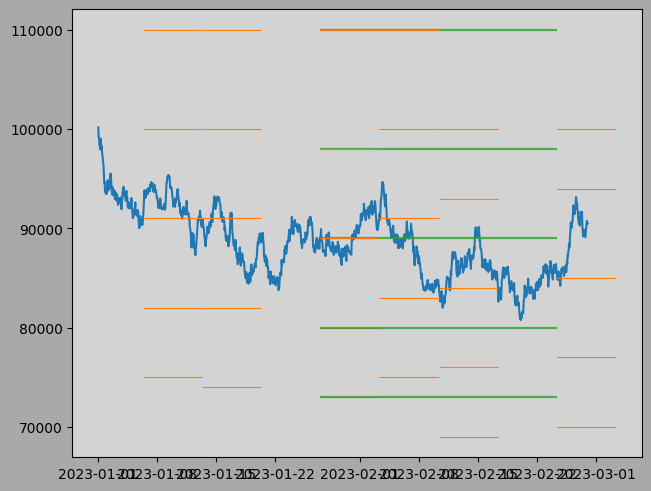

In [6]:
fig, ax = plt.subplots(layout="constrained")
ax.plot(
    paths_mark.filter(pl.col("name").eq("btc")).collect()["time_end"],
    paths_mark.filter(pl.col("name").eq("btc")).collect()["price"],
)
for k, tl, te in bars_option.select(["strike", "listing", "expiry"]).unique().collect().iter_rows():  # fmt: off
    dw = abs((te - tl) - timedelta(days=7))
    dm = abs((te - tl) - timedelta(days=30))
    dq = abs((te - tl) - timedelta(days=90))

    alphas = {dw: 1.0, dm: 0.8, dq: 0.2}
    colors = {dw: "tab:orange", dm: "tab:green", dq: "tab:red"}
    widths = {dw: 0.8, dm: 1.6, dq: 3.2}

    a = alphas[min(alphas.keys())]
    c = colors[min(colors.keys())]
    w = widths[min(widths.keys())]

    ax.hlines(k, tl, te, alpha=a, color=c, linewidth=w)

In [7]:
target_option = io.get_target_option(
    path_rate,
    bars_spot,
    bars_option,
    "drbt",
    "btc",
    "usd",
    "c",
    SpotInstrument("cbse", "btc", "usd"),
    target_time=tt,
    target_delta=0.50,
    target_tenor=timedelta(days=30),
)
target_option

OptionInstrument(exchange='drbt', base='btc', quote='usd', strike=91000.0, listing=datetime.datetime(2023, 1, 13, 8, 0, tzinfo=zoneinfo.ZoneInfo(key='UTC')), expiry=datetime.datetime(2023, 1, 20, 8, 0, tzinfo=zoneinfo.ZoneInfo(key='UTC')), kind='c')

In [8]:
io.get_bars_option(bars_option, target_option, start_time=t0, end_time=tf).show()

time_start,time_end,exchange,base,quote,strike,listing,expiry,kind,iv_bid,iv_ask,iv_mark
"datetime[μs, UTC]","datetime[μs, UTC]",str,str,str,f64,"datetime[μs, UTC]","datetime[μs, UTC]",str,f64,f64,f64
2023-01-13 08:00:00 UTC,2023-01-13 09:00:00 UTC,"""drbt""","""btc""","""usd""",91000.0,2023-01-13 08:00:00 UTC,2023-01-20 08:00:00 UTC,"""c""",0.99,1.01,1.0
2023-01-13 09:00:00 UTC,2023-01-13 10:00:00 UTC,"""drbt""","""btc""","""usd""",91000.0,2023-01-13 08:00:00 UTC,2023-01-20 08:00:00 UTC,"""c""",0.99,1.01,1.0
2023-01-13 10:00:00 UTC,2023-01-13 11:00:00 UTC,"""drbt""","""btc""","""usd""",91000.0,2023-01-13 08:00:00 UTC,2023-01-20 08:00:00 UTC,"""c""",0.99,1.01,1.0
2023-01-13 11:00:00 UTC,2023-01-13 12:00:00 UTC,"""drbt""","""btc""","""usd""",91000.0,2023-01-13 08:00:00 UTC,2023-01-20 08:00:00 UTC,"""c""",0.99,1.01,1.0
2023-01-13 12:00:00 UTC,2023-01-13 13:00:00 UTC,"""drbt""","""btc""","""usd""",91000.0,2023-01-13 08:00:00 UTC,2023-01-20 08:00:00 UTC,"""c""",0.99,1.01,1.0


In [9]:
io.get_bars_spot(
    bars_spot, SpotInstrument("cbse", "btc", "usd"), start_time=t0, end_time=tf
).show()

time_start,time_end,base,px_mark,exchange,quote,px_bid,px_ask
"datetime[μs, UTC]","datetime[μs, UTC]",str,f64,str,str,f64,f64
2023-01-01 00:00:00 UTC,2023-01-01 01:00:00 UTC,"""btc""",100159.118831,"""cbse""","""usd""",99157.527643,101160.71002
2023-01-01 01:00:00 UTC,2023-01-01 02:00:00 UTC,"""btc""",99174.920298,"""cbse""","""usd""",98183.171095,100166.669501
2023-01-01 02:00:00 UTC,2023-01-01 03:00:00 UTC,"""btc""",99017.255773,"""cbse""","""usd""",98027.083216,100007.428331
2023-01-01 03:00:00 UTC,2023-01-01 04:00:00 UTC,"""btc""",98379.906424,"""cbse""","""usd""",97396.10736,99363.705488
2023-01-01 04:00:00 UTC,2023-01-01 05:00:00 UTC,"""btc""",98345.814495,"""cbse""","""usd""",97362.35635,99329.27264


In [10]:
# NOTE: ~21.6s using duckdb for one month of data at dt=1h.
#       near-instant for Polars.
io._build_lf_priced(
    path_rate,
    bars_spot,
    bars_option,
    "drbt",
    "btc",
    "usd",
    "cbse",
    "btc",
    "usd",
).collect()

time_start,time_end,exchange,base,quote,strike,listing,expiry,kind,spot,rate,iv_bid,iv_ask,iv_mark,px_bid,px_ask,px_mark,delta,gamma,vega,theta,rho
"datetime[μs, UTC]","datetime[μs, UTC]",str,str,str,f64,"datetime[μs, UTC]","datetime[μs, UTC]",str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2023-02-27 23:00:00 UTC,2023-02-28 00:00:00 UTC,"""drbt""","""btc""","""usd""",100000.0,2023-02-24 08:00:00 UTC,2023-03-03 08:00:00 UTC,"""c""",90475.483158,0.050146,0.99,1.01,1.0,676.288585,718.346784,697.20362,0.159915,0.000028,2102.909944,-115828.89353,125.764463
2023-02-27 22:00:00 UTC,2023-02-27 23:00:00 UTC,"""drbt""","""btc""","""usd""",100000.0,2023-02-24 08:00:00 UTC,2023-03-03 08:00:00 UTC,"""c""",90438.097775,0.050326,0.99,1.01,1.0,683.342027,725.751355,704.432171,0.160532,0.000028,2120.466433,-115361.434209,127.730118
2023-02-27 21:00:00 UTC,2023-02-27 22:00:00 UTC,"""drbt""","""btc""","""usd""",100000.0,2023-02-24 08:00:00 UTC,2023-03-03 08:00:00 UTC,"""c""",90754.29159,0.05036,0.99,1.01,1.0,748.098868,792.735089,770.306115,0.171189,0.000029,2231.811014,-119958.953378,138.219054
2023-02-27 20:00:00 UTC,2023-02-27 21:00:00 UTC,"""drbt""","""btc""","""usd""",100000.0,2023-02-24 08:00:00 UTC,2023-03-03 08:00:00 UTC,"""c""",90518.203589,0.050427,0.99,1.01,1.0,722.162172,766.085725,744.010283,0.166061,0.000028,2196.177617,-116619.098757,135.372738
2023-02-27 19:00:00 UTC,2023-02-27 20:00:00 UTC,"""drbt""","""btc""","""usd""",100000.0,2023-02-24 08:00:00 UTC,2023-03-03 08:00:00 UTC,"""c""",90025.806785,0.050662,0.99,1.01,1.0,657.365987,699.212349,678.170066,0.154078,0.000027,2092.318066,-109771.685733,126.506629
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2023-01-06 12:00:00 UTC,2023-01-06 13:00:00 UTC,"""drbt""","""btc""","""usd""",75000.0,2023-01-06 08:00:00 UTC,2023-01-13 08:00:00 UTC,"""p""",93013.885772,0.04993,0.99,1.01,1.0,261.053371,286.871892,273.800814,-0.049158,0.000008,1290.92602,-34447.44428,-90.173564
2023-01-06 11:00:00 UTC,2023-01-06 12:00:00 UTC,"""drbt""","""btc""","""usd""",75000.0,2023-01-06 08:00:00 UTC,2023-01-13 08:00:00 UTC,"""p""",93811.332628,0.049905,0.99,1.01,1.0,228.947,252.647131,240.637518,-0.043552,0.000007,1185.006569,-31432.887427,-80.99507
2023-01-06 10:00:00 UTC,2023-01-06 11:00:00 UTC,"""drbt""","""btc""","""usd""",75000.0,2023-01-06 08:00:00 UTC,2023-01-13 08:00:00 UTC,"""p""",93012.09116,0.050078,0.99,1.01,1.0,268.752566,295.127772,281.77688,-0.050106,0.000008,1318.760298,-34760.358426,-93.090812


In [11]:
io.get_target_option(
    path_rate,
    bars_spot,
    bars_option,
    "drbt",
    "btc",
    "usd",
    "c",
    SpotInstrument("cbse", "btc", "usd"),
    target_time=tt,
    target_delta=0.50,
    target_tenor=timedelta(days=30),
)

OptionInstrument(exchange='drbt', base='btc', quote='usd', strike=91000.0, listing=datetime.datetime(2023, 1, 13, 8, 0, tzinfo=zoneinfo.ZoneInfo(key='UTC')), expiry=datetime.datetime(2023, 1, 20, 8, 0, tzinfo=zoneinfo.ZoneInfo(key='UTC')), kind='c')